# VaR and ES-forecast
**Category: Quantiative Risk Management**

## Data & Setup

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stat

In [61]:
DAX = pd.read_csv("GDAXI.csv")
DAX = DAX.iloc[::-1].reset_index(drop=True)

DAX.head()

,Date,Open,High,Low,Close
0,01/03/00,6961.72,6750.76,6750.76,6750.76
1,01/04/00,6747.24,6586.95,6586.95,6586.95
2,01/05/00,6585.85,6502.07,6502.07,6502.07
3,01/06/00,6501.45,6474.92,6474.92,6474.92
4,01/07/00,6489.94,6780.96,6780.96,6780.96


In [62]:
add_yr = lambda series : ("20"+series.str[-2:]).astype(int)
ticks_loc = lambda df : [df[df["Year"] == y].index[0] for y in np.unique(df["Year"])]


S_t = DAX[" Close"]
DAX["Year"] = add_yr(DAX["Date"])
DAX_ticks = ticks_loc(DAX)


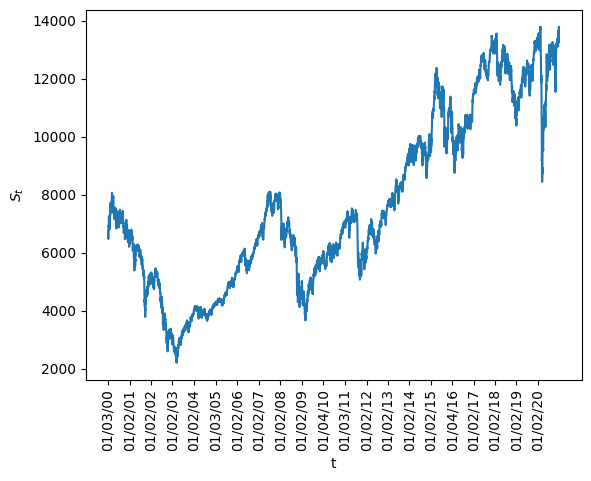

In [63]:
plt.plot(DAX["Date"],S_t)
plt.xticks(DAX["Date"][DAX_ticks],rotation=90)
plt.xlabel("t")
plt.ylabel(fr"$S_t$")
plt.show()

01/03/05


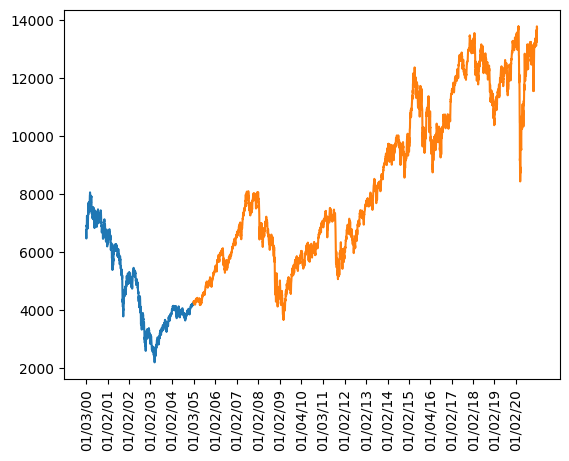

In [201]:
S_t_train = S_t[0:1270]
S_t_test = S_t[1270:]
print(DAX["Date"][1270])
plt.plot(DAX["Date"][0:1270],S_t_train)
plt.plot(DAX["Date"][1270:],S_t_test)

plt.xticks(DAX["Date"][DAX_ticks],rotation=90)

plt.show()

In [206]:
log_return = lambda series : np.log(series/series.shift(1))


ValueError: x and y must have same first dimension, but have shapes (4060,) and (4059,)

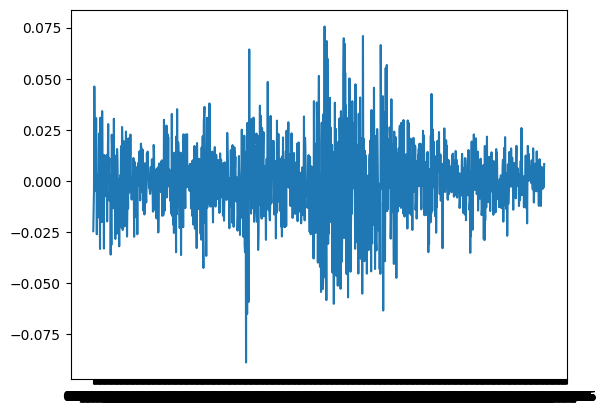

In [213]:
X = log_return(DAX[" Close"]).dropna().values
X_test = X[1270:]
X_train = X[0:1270]
plt.plot(DAX["Date"][0:1270],X_train)
plt.plot(DAX["Date"][1270:],X_test)

plt.xticks(DAX["Date"][DAX_ticks],rotation=90)

plt.show()

### Expected Shortal and VaR

In [203]:
alpha = 0.025
p = 1-alpha

#### Covariance-Variance Method

In [204]:
mu_ser = np.mean(X_train)
sigma_2_ser = np.var(X_train,ddof=1)
mu = -100*mu_ser
sigma_2 = (-100)**2*sigma_2_ser

print(mu)
print(np.sqrt(sigma_2))

0.036351973387218094
1.836353743407955


Note for $X\sim\mathcal{N}(\mu,\sigma^2)$, we can take 

$$\text{VaR}_{\alpha}(X) = \mu+\sigma\Phi^{-1}(\alpha)$$


Since $Z = \frac{X-\mu}{\sigma}\sim \mathcal{N}(0,1)$, hence $X = \mu+\sigma Z$, and with trivial computations

$$ES_{\alpha}(Z) = \mathbb{E}[Z|Z\geq \text{VaR}_{\alpha}] = \frac{\int^{\infty}_{-\Phi^{-1}(\alpha)}z\varphi(z)dz}{1-\alpha} = \frac{\varphi(\Phi^{-1}(\alpha))}{1-\alpha}$$

3.635539173342118
4.3293848821958525


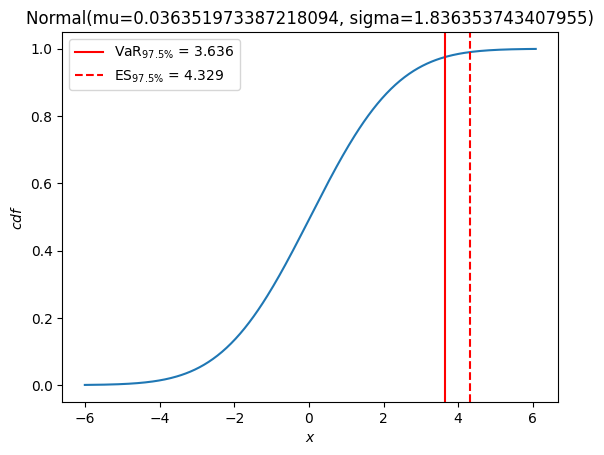

In [196]:
L_dist = stat.Normal(mu=mu,sigma=np.sqrt(sigma_2))
VaR_975_cv = mu+np.sqrt(sigma_2)*stat.norm.ppf(p)
ES_975_cv = mu+(np.sqrt(sigma_2)*stat.norm.pdf(stat.norm.ppf(p)))/(1-p)
print(VaR_975_cv)
print(ES_975_cv)

L_dist.plot(y='cdf')
plt.axvline(VaR_975_cv,color="red",label=fr"VaR$_{{97.5\%}}$ = {round(VaR_975_cv,3)}")
plt.axvline(ES_975_cv,color='red',linestyle='--',label=fr"ES$_{{97.5\%}}$ = {round(ES_975_cv,3)}")

plt.legend()
plt.show()

#### Historical Simulation

3.941215411445646
5.049904521525052


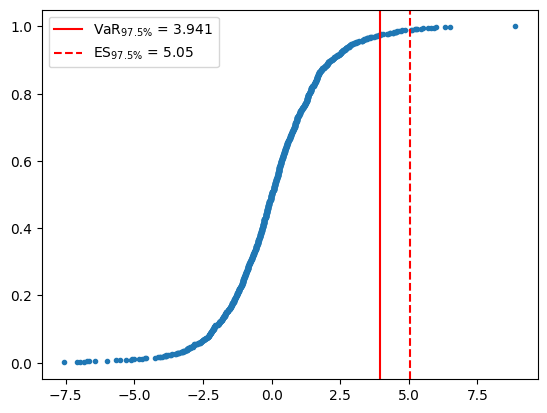

1.0840800287189651
1.1664254065958104


In [193]:
L_train = -100*X_train
historical_train = L_train.value_counts(normalize=True).sort_index()
hist_cdf_train = np.cumsum(historical_train.values)
VaR_975_hist = np.quantile(historical_train.index,p)
ES_975_hist = np.mean(historical_train.index[historical_train.index>=VaR_975_hist])
plt.plot(historical_train.index,hist_cdf_train,'.')
print(VaR_975_hist)
print(ES_975_hist)
plt.axvline(VaR_975_hist,color="red",label=fr"VaR$_{{97.5\%}}$ = {round(VaR_975_hist,3)}")
plt.axvline(ES_975_hist,color='red',linestyle='--',label=fr"ES$_{{97.5\%}}$ = {round(ES_975_hist,3)}")
plt.legend()
plt.show()

print(VaR_975_hist/VaR_975_cv)
print(ES_975_hist/ES_975_cv)


#### Comparison

**Covariance-Variance method under the normality assumption**

* It is very nice mathematically, but it is clear from above that it totally underestimates tails, with the VaR being approximately $8\%$ smaller and the expected shortfall almost $17\%$ smaller than what is observed using the historical estimate. Eventhough the historical estimate isn't perfect, looking at an underestimate of a risk measure of potentially $17\%$ is severe.

* One noticable aspect is that these are daily values, hence the amount of data is not small in comparison to longer period, the conclusion is simple that if we compare these on shorter periods the historical simulation should always be a clear winner, assuming one wants to mitigate risks (not be neutral or seeking).

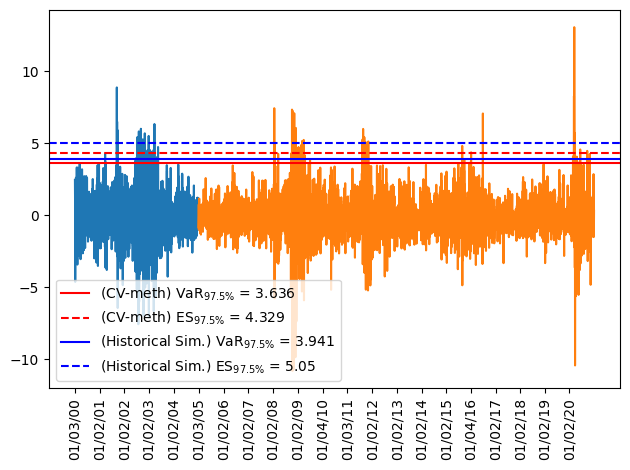

In [192]:
L_test = -100*X_test
plt.plot(DAX["Date"][0:1270],L_train)
plt.plot(DAX["Date"][1270:],L_test)
plt.xticks(DAX["Date"][DAX_ticks],rotation=90)

plt.axhline(VaR_975_cv,color="red",label=fr"(CV-meth) VaR$_{{97.5\%}}$ = {round(VaR_975_cv,3)}")
plt.axhline(ES_975_cv,color='red',linestyle='--',label=fr"(CV-meth) ES$_{{97.5\%}}$ = {round(ES_975_cv,3)}")
plt.axhline(VaR_975_hist,color="blue",label=fr"(Historical Sim.) VaR$_{{97.5\%}}$ = {round(VaR_975_hist,3)}")
plt.axhline(ES_975_hist,color='blue',linestyle='--',label=fr"(Historical Sim.) ES$_{{97.5\%}}$ = {round(ES_975_hist,3)}")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [72]:
def exceedance_pct(losses, var):
    return np.mean(losses > var) * 100

def mean_excess(losses, var):
    breaches = losses[losses > var]
    return np.mean(breaches - var)

exceedance_ratio_test_cv   = exceedance_pct(L_test, VaR_975_cv)
exceedance_ratio_train_cv  = exceedance_pct(L_train, VaR_975_cv)
exceedance_ratio_test_hist = exceedance_pct(L_test, VaR_975_hist)
exceedance_ratio_train_hist = exceedance_pct(L_train, VaR_975_hist)


mean_excess_ratio_test_cv   = mean_excess(L_test, VaR_975_cv)
mean_excess_ratio_train_cv  = mean_excess(L_train, VaR_975_cv)
mean_excess_ratio_test_hist = mean_excess(L_test, VaR_975_hist)
mean_excess_ratio_train_hist = mean_excess(L_train, VaR_975_hist)

print(exceedance_ratio_test_cv,exceedance_ratio_train_cv)
print(exceedance_ratio_test_hist,exceedance_ratio_train_hist)

print(mean_excess_ratio_test_cv,mean_excess_ratio_train_cv)
print(mean_excess_ratio_test_hist,mean_excess_ratio_train_hist)

0.8866995073891626 2.283464566929134
0.6896551724137931 1.2598425196850394
1.5404111289085094 1.006033213303648
1.3473857328996037 1.0072333173191386


There are a few things to consider, namely:
* It is clear that the Covariance-Variance method severely underestimates the tail exposure on the training data, and it happens to be so that it is fine (from a conservative view on the testing data) WHEN comparing the value at risk, however the amount lost is approximately $54\%$ higher under the training regime vs testing regime, (it is significant as well when one looks as the historical simulation).
* Both methods would need some calibration, the current setting is far from optimal, on hand it might be extremely costly to underestimate exposure, on the other the assumption that the daily market data behaves in the same manner as it did several (at most 15) years ago is asburd. Even a very slight calibration would yield to much tighter bounds (keeping exposure limited, whilst not limiting returns totally).

### Dynamic risk measure modelling

In [73]:
from arch import arch_model
model = arch_model(L_train[1:],p=1,q=1,vol="GARCH")
res = model.fit(disp='off')
print(res.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2373.63
Distribution:                  Normal   AIC:                           4755.25
Method:            Maximum Likelihood   BIC:                           4775.84
                                        No. Observations:                 1269
Date:                Mon, Apr 06 2026   Df Residuals:                     1268
Time:                        22:18:11   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu            -0.0164  3.698e-02     -0.444      0.657 

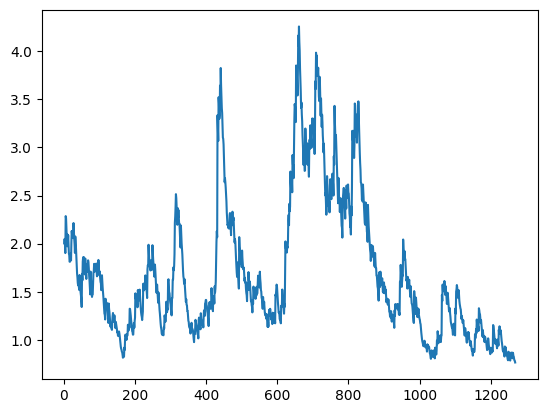

In [94]:
plt.plot(res.conditional_volatility)
plt.show()

In [74]:
print(res.params.keys())

Index(['mu', 'omega', 'alpha[1]', 'beta[1]'], dtype='str')


In [75]:
alpha0 = res.params["omega"]; alpha1 = res.params["alpha[1]"]; beta = res.params["beta[1]"]
print(alpha0,alpha1,beta)

0.02252653476966158 0.0915772042990429 0.9019353539723943


In [ ]:
# def GARCH_1_1(alpha0,alpha1,beta,T,SWN_func,dist_params):


#     if SWN_func.__name__ == "normal":
#         w = SWN_func(dist_params[0],dist_params[1],T)

#         z = (w-dist_params[0])/np.sqrt(dist_params[1])

#     if SWN_func.__name__ == "randint":
#         w = SWN_func(dist_params[0],dist_params[1]+1,T)

#         a = dist_params[0]
#         b = dist_params[1]
#         mu = (a+b)/2
#         var = ((b-a+1)**2-1)/12
#         z = (w-mu)/np.sqrt(var)

#     if SWN_func == "Home":
#         X = dist_params
#         sigma = np.zeros(shape=(T))
#         sigma[0] = np.sqrt(x_var) 
#         for t in range(1,T):
#             sigma[t] = np.sqrt(alpha0+alpha1*X[t-1]**2+beta*sigma[t-1]**2)


#     else:

#         x_var = alpha0/(1-(alpha1+beta))
#         X = np.zeros(shape=(T))
#         sigma = np.zeros(shape=(T))
#         sigma[0] = np.sqrt(x_var) 
#         X[0] = sigma[0]*z[0]
#         for t in range(1,T):
#             sigma[t] = np.sqrt(alpha0+alpha1*X[t-1]**2+beta*sigma[t-1]**2)
#             X[t] = sigma[t]*z[t]

#         return X,z,sigma

In [163]:
X = np.append(L_train,L_test)
X = X[~np.isnan(X)]
Sigma = np.zeros(shape=(len(X)))
Sigma[0] = np.std(L_train,ddof=1)
for i in range(1,len(X)):
    Sigma[i] = np.sqrt(alpha0+alpha1*X[i-1]**2+beta*Sigma[i-1]**2)


print(Sigma)

[1.83635374 1.90174302 1.85432948 ... 1.30264083 1.3245826  1.2684725 ]


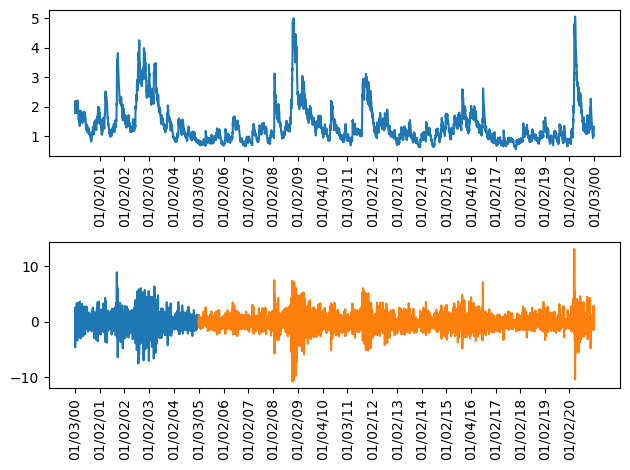

In [168]:
plt.subplot(2,1,1)
plt.plot(DAX["Date"][1:len(DAX)-1],Sigma)
plt.xticks(DAX["Date"][DAX_ticks],rotation=90)

plt.subplot(2,1,2)


plt.plot(DAX["Date"][0:1270],L_train)
plt.plot(DAX["Date"][1270:],L_test)
plt.xticks(DAX["Date"][DAX_ticks],rotation=90)

# plt.xticks(DAX["Date"][DAX_ticks],rotation=90)
plt.tight_layout()
plt.show()

First there are clear volatility clusters as expected, we should keep in mind that the simulated volatility path only corresponds to the estimates based on the first 5 years, hence they're not perfect, and lastly it is a single generated path (it only gives a partial idea, though clear)

We recall the 6 stylized facts for the univariate case:

* (U1): Returns are iid although they show little serial correlation (we can argue that this is the case but we need acf/pacf analysis to draw a conclusion)
* (U2): Series of absolute or squared returns show profound serial correlation (same as U1 we could argue for this but we need to do further analysis)
* (U3): Conditional expected returns are close to zero (as observed above)
* (U4): Volatility (conditional standard deviation) appears to vary over time (this is very clear from the above)
* (U5): Extreme returns appear in clusters (this is very clear as well)
* (U6): Return series are leptokurtic or heavy-tailed (power-like tail) (this is rather clear based on the normality assumption and the comparison of the CDFs above, for a clearer answer we need to compare the quantiles and do a little more)


In [176]:
Z_hat = X[0:1270]/Sigma[0:1270]
s_mean = np.mean(Z_hat)
s_std = np.std(Z_hat,ddof=1)
print(s_mean,s_std)

0.030953847875578668 1.0011737904099094


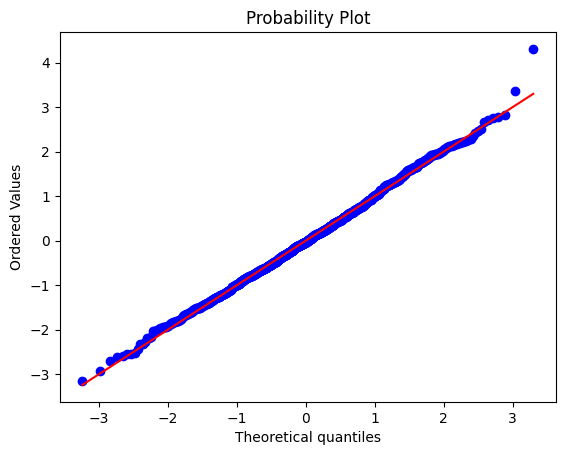

In [177]:
stat.probplot(Z_hat[1:], dist=stat.norm(loc=s_mean, scale=s_std), plot=plt)

plt.show()

It is clear that the residuals roughly matches a normal distribution.

In [178]:
# def covar_var(series):
#     mu_ser = np.mean(series)
#     sigma_2_ser = np.var(series,ddof=1)
#     mu = mu_ser
#     sigma_2 = sigma_2_ser

#     VaR_975_cv = mu+np.sqrt(sigma_2)*stat.norm.ppf(p)
#     ES_975_cv = mu+(np.sqrt(sigma_2)*stat.norm.pdf(stat.norm.ppf(p)))/(1-p)
    
#     return VaR_975_cv,ES_975_cv

# def hist_simulation(series):
#     historical_train = series.value_counts(normalize=True).sort_index()
#     hist_cdf_train = np.cumsum(historical_train.values)
#     VaR_975_hist = np.quantile(historical_train.index,p)
#     ES_975_hist = np.mean(historical_train.index[historical_train.index>=VaR_975_hist])
#     # plt.plot(historical_train.index,hist_cdf_train,'.')
    
#     return VaR_975_hist,ES_975_hist


def var_es_comp(series,vol,shift):
    VaR_975_cv = shift+vol*stat.norm.ppf(p)
    ES_975_cv = shift+vol*stat.norm.pdf(stat.norm.ppf(p))/(1-p)

    VaR_975_hist = np.zeros(len(series))
    ES_975_hist = np.zeros(len(series))
    for i in range(len(series)):
        loss = shift+vol[i]*series
        historical_train = loss.value_counts(normalize=True).sort_index()
        VaR_975_hist[i] = np.quantile(historical_train.index,p)
        ES_975_hist[i] = np.mean(historical_train.index[historical_train.index>=VaR_975_hist])

    return VaR_975_cv,ES_975_cv,VaR_975_hist,ES_975_hist

In [179]:
VaR_975_cv_Z =s_mean+s_std*stat.norm.ppf(p)
ES_975_cv_Z = s_mean+s_std*stat.norm.pdf(stat.norm.ppf(p))/(1-p)



# VaR_975_hist_Z, ES_975_hist_Z = hist_simulation(Z_hat[:1270]*Sigma[:1270])

In [180]:
print(VaR_975_cv_Z, ES_975_cv_Z)
# print(VaR_975_hist_Z, ES_975_hist_Z)


2.274987512506933 2.622664418968458


In [137]:
VaR_975_cv_L,ES_975_cv_L,VaR_975_hist_L,ES_975_hist_L = var_es_comp(Z_hat,Sigma,s_std)

ValueError: Lengths must match to compare